# Entregable 1: Importación de Librerías, Configuración del Entorno y Carga de Datos

En este primer paso cargamos todas las librerías necesarias para el procesamiento de datos, visualización y construcción de modelos de Machine Learning en Google Colab. Además, fijamos la semilla aleatoria (`SEED = 42`) para garantizar que los experimentos sean reproducibles y habilitamos la carga directa del archivo `Churn_Modelling.csv`.

In [12]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

print("Google Drive montado con éxito y semilla configurada.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado con éxito y semilla configurada.


# Entregable 2: Carga del Dataset desde Google Drive y Exploración Inicial (EDA - Parte 1)

Cargamos el dataset `Churn_Modelling.csv` Desplegamos las dimensiones del archivo, visualizamos las primeras filas para verificar su formato y revisamos los tipos de datos junto con la presencia de valores nulos.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Algoritmos de AA/CSV/Churn_Modelling.csv")

display(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geogr

# Entregable 3: Limpieza de Datos y Selección de Características

Eliminamos del conjunto de datos las columnas `RowNumber`, `CustomerId` y `Surname`. Estas variables son identificadores únicos o información personal que no aportan valor predictivo para saber si un cliente abandonará el banco y podrían distorsionar el aprendizaje de los modelos.

In [14]:
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=cols_to_drop)

print(df_clean.shape)
print(df_clean.columns.tolist())

(10000, 11)
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


# Entregable 4: Análisis de la Variable Objetivo y Proporción de Clases (EDA - Parte 2)

Visualizamos la distribución de la variable objetivo `Exited` (0 representa clientes retenidos y 1 representa clientes que abandonaron el banco) para evaluar el nivel de desbalance de clases y calculamos el porcentaje general de tasa de abandono (*Churn Rate*).

/tmp/ipykernel_1067/4273139818.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Exited', data=df_clean, palette='Set2')


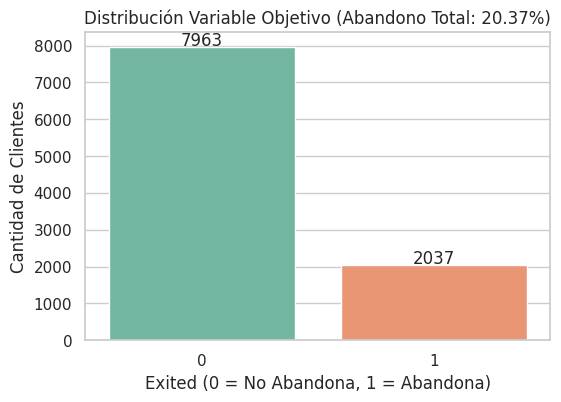

/tmp/ipykernel_1067/4273139818.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Exited', y='Age', data=df_clean, palette='Set2')
/tmp/ipykernel_1067/4273139818.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(ax=axes[1], x='Geography', y='Exited', data=df_clean, palette='Set2', ci=None)
/tmp/ipykernel_1067/4273139818.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Geography', y='Exited', data=df_clean, palette='Set2', ci=None)
/tmp/ipykernel_1067/4273139818.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(ax=axes[2], x='Num

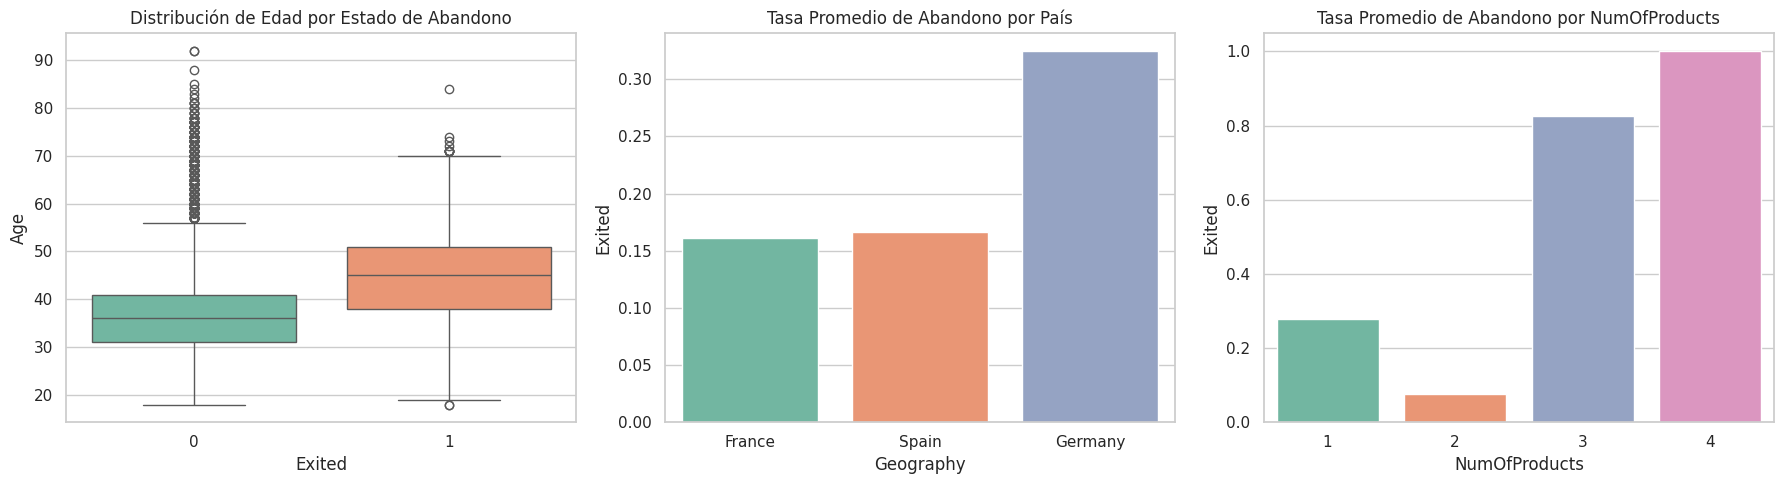

In [15]:
churn_counts = df_clean['Exited'].value_counts()
churn_rate = df_clean['Exited'].mean() * 100

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Exited', data=df_clean, palette='Set2')
plt.title(f'Distribución Variable Objetivo (Abandono Total: {churn_rate:.2f}%)')
plt.xlabel('Exited (0 = No Abandona, 1 = Abandona)')
plt.ylabel('Cantidad de Clientes')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], x='Exited', y='Age', data=df_clean, palette='Set2')
axes[0].set_title('Distribución de Edad por Estado de Abandono')

sns.barplot(ax=axes[1], x='Geography', y='Exited', data=df_clean, palette='Set2', ci=None)
axes[1].set_title('Tasa Promedio de Abandono por País')

sns.barplot(ax=axes[2], x='NumOfProducts', y='Exited', data=df_clean, palette='Set2', ci=None)
axes[2].set_title('Tasa Promedio de Abandono por NumOfProducts')

plt.tight_layout()
plt.show()

# Entregable 5: Preprocesamiento de Datos (Codificación y Escalamiento)

Preparamos los datos para los modelos de Machine Learning. Separamos la variable respuesta (`y`) de las características (`X`). Aplicamos `OneHotEncoder` a las variables categóricas (`Geography` y `Gender`) y escalamos las variables numéricas al rango [0, 1] utilizando `MinMaxScaler` con la ayuda de `ColumnTransformer`.

In [16]:
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.17647, random_state=SEED, stratify=y_train_val
)

print(X_train.shape[0], X_val.shape[0], X_test.shape[0])
print(y_train.mean(), y_val.mean(), y_test.mean())

7000 1500 1500
0.2037142857142857 0.20333333333333334 0.204


# Entregable 6: División del Conjunto de Datos (Train / Test Split)

Dividimos los datos procesados en un 80% para entrenamiento de modelos y un 20% para la evaluación final en datos no vistos. Utilizamos el parámetro `stratify=y` para conservar la misma proporción de clases en ambos subconjuntos.

In [17]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
cat_cols = ['Geography', 'Gender']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# Entregable 7: Entrenamiento y Comparación de Modelos de Clasificación

Entrenamos cuatro algoritmos distintos: Regresión Logística, Máquinas de Vectores de Soporte (SVM), Random Forest y Gradient Boosting. Evaluamos la capacidad discriminativa de cada uno calculando el área bajo la curva ROC (`ROC-AUC Score`).

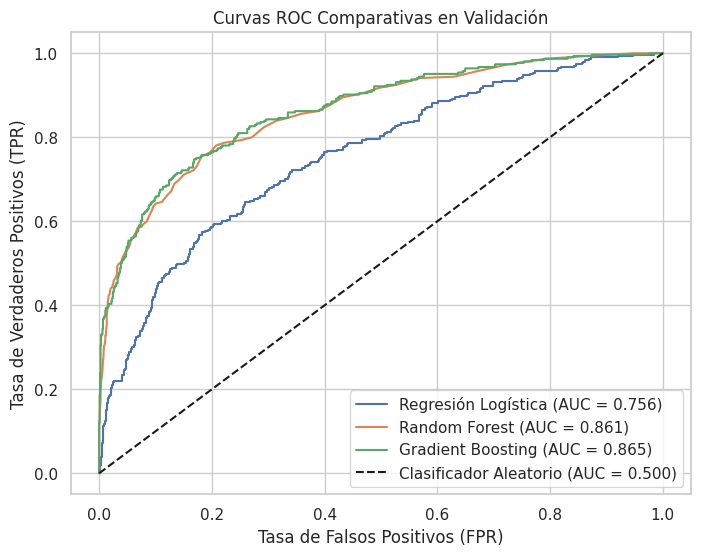

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,DummyClassifier (Baseline),0.796667,0.000000,0.000000,0.000000,0.500000
1,Regresión Logística,0.809333,0.581197,0.222951,0.322275,0.755939
2,Random Forest,0.868000,0.768844,0.501639,0.607143,0.860682
3,Gradient Boosting,0.866000,0.765306,0.491803,0.598802,0.865472


In [18]:
models = {
    'DummyClassifier (Baseline)': DummyClassifier(strategy='most_frequent'),
    'Regresión Logística': LogisticRegression(random_state=SEED),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED)
}

results = []

plt.figure(figsize=(8, 6))

for name, clf in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_val)[:, 1]
    else:
        y_prob = [0] * len(y_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_prob) if len(np.unique(y_val)) > 1 and sum(y_prob) > 0 else 0.5

    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': auc
    })

    if name != 'DummyClassifier (Baseline)':
        fpr, tpr, _ = roc_curve(y_val, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.500)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Comparativas en Validación')
plt.legend(loc='lower right')
plt.show()

df_results = pd.DataFrame(results)
display(df_results)

# Entregable 8: Evaluación Final, Matriz de Confusión y Ajuste de Umbral

Tomamos el mejor modelo (Gradient Boosting) y ajustamos el umbral de decisión a `0.35` para optimizar la sensibilidad (*Recall*) sobre la clase de riesgo (clientes que se van del banco). Mostramos la matriz de confusión detallada y el reporte de métricas clave (Precision, Recall y F1-Score).

,Umbral (t),Accuracy,Precision,Recall,F1-score
0,0.5,0.866000,0.765306,0.491803,0.598802
1,0.4,0.866000,0.722222,0.554098,0.627087
2,0.3,0.854000,0.640523,0.642623,0.641571
3,0.2,0.808667,0.520455,0.750820,0.614765


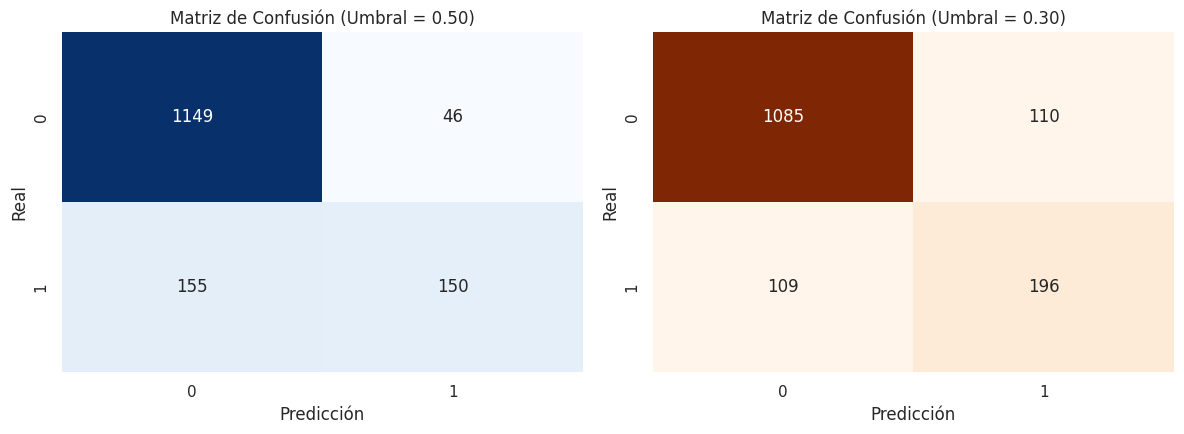

In [19]:
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=SEED))
])
gb_pipeline.fit(X_train, y_train)

y_val_probs = gb_pipeline.predict_proba(X_val)[:, 1]

thresholds = [0.50, 0.40, 0.30, 0.20]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_val_probs >= t).astype(int)
    threshold_results.append({
        'Umbral (t)': t,
        'Accuracy': accuracy_score(y_val, y_pred_t),
        'Precision': precision_score(y_val, y_pred_t, zero_division=0),
        'Recall': recall_score(y_val, y_pred_t, zero_division=0),
        'F1-score': f1_score(y_val, y_pred_t, zero_division=0)
    })

df_thresholds = pd.DataFrame(threshold_results)
display(df_thresholds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm_050 = confusion_matrix(y_val, (y_val_probs >= 0.50).astype(int))
sns.heatmap(cm_050, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión (Umbral = 0.50)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

cm_030 = confusion_matrix(y_val, (y_val_probs >= 0.30).astype(int))
sns.heatmap(cm_030, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión (Umbral = 0.30)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()